# Week 3 — RFM Customer Analysis

## 1. Project Objective

Weeks 1-2 established a validated, one-row-per-`order_id` analytical extract
(`data/processed/olist_order_level_cleaned.csv`). That extract is still at **order grain**:
a customer who placed three orders appears as three separate rows.

**Goal of Week 3:** transition from order-level data to **customer-level analytics** by
computing **RFM** (Recency, Frequency, Monetary) metrics -- the standard, widely-used
framework for describing purchasing behavior:

- **Recency (R)** -- how recently a customer last purchased (lower = more engaged)
- **Frequency (F)** -- how often a customer has purchased (higher = more loyal)
- **Monetary (M)** -- how much a customer has spent (higher = more valuable)

**Why `customer_unique_id` and not `customer_id`:** Week 1 established that `customer_id` is
an **order-scoped** identifier (Olist issues a new `customer_id` for every order, even for a
repeat shopper), while `customer_unique_id` is the **persistent real-customer** identifier that
correctly links a shopper's multiple orders together. RFM is a *customer*-level concept, so
grouping by `customer_id` would (incorrectly) treat every order as a brand-new, one-time
customer and make Frequency always equal to 1. All RFM aggregation in this notebook therefore
groups by `customer_unique_id`.

This RFM dataset (one row per `customer_unique_id`) becomes the direct foundation for Week 4
(CLV) and later segmentation -- **no CLV or segmentation is performed in this notebook.**

## 2. Load Week 2 Analytical Extract

The validated Week 2 output is loaded as-is. The raw Olist tables are **not** reloaded --
every column required for RFM (`customer_unique_id`, `order_status`, `order_purchase_timestamp`,
`total_product_value`, `order_id`) is already present in the Week 2 extract, so re-joining the
raw tables would add risk without adding information.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Environment setup successful!")

Python: 3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]
Pandas: 3.0.5
Environment setup successful!


In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")
OUTPUT_DATA_DIR = Path("../data/output")

order_level_path = PROCESSED_DATA_DIR / "olist_order_level_cleaned.csv"
order_level = pd.read_csv(order_level_path)

# Parse the purchase timestamp once, up front -- this is an in-memory dtype conversion on a
# freshly-loaded copy in THIS notebook; it does not touch the Week 2 CSV file on disk.
order_level["order_purchase_timestamp"] = pd.to_datetime(order_level["order_purchase_timestamp"])

print(f"Loaded '{order_level_path}':")
print(f"  rows:    {len(order_level):,}")
print(f"  columns: {order_level.shape[1]}")

Loaded '../data/processed/olist_order_level_cleaned.csv':
  rows:    99,441
  columns: 24


In [3]:
# Structural verification of everything Week 3 depends on -- fail loudly and early if the
# Week 2 extract does not have what this notebook assumes.
required_columns = [
    "order_id", "customer_unique_id", "order_status",
    "order_purchase_timestamp", "total_product_value", "total_freight_value",
]
missing_columns = [c for c in required_columns if c not in order_level.columns]
assert not missing_columns, f"Week 2 extract is missing required columns: {missing_columns}"

order_id_unique = bool(order_level["order_id"].is_unique)
assert order_id_unique, "order_id is not unique in the Week 2 extract -- cannot proceed."

structural_checks = pd.DataFrame([
    {"check": "row count", "value": f"{len(order_level):,}"},
    {"check": "column count", "value": f"{order_level.shape[1]}"},
    {"check": "order_id is unique", "value": str(order_id_unique)},
    {"check": "customer_unique_id present", "value": str("customer_unique_id" in order_level.columns)},
    {"check": "distinct customer_unique_id values", "value": f"{order_level['customer_unique_id'].nunique():,}"},
    {"check": "order_status present", "value": str("order_status" in order_level.columns)},
    {"check": "order_purchase_timestamp present (dtype)", "value": str(order_level["order_purchase_timestamp"].dtype)},
    {"check": "total_product_value present", "value": str("total_product_value" in order_level.columns)},
])
display(structural_checks)

,check,value
0,row count,"99,441"
1,column count,24
2,order_id is unique,True
3,customer_unique_id present,True
4,distinct customer_unique_id values,"96,096"
5,order_status present,True
6,order_purchase_timestamp present (dtype),datetime64[us]
7,total_product_value present,True


## 3. Inspect Order Statuses

Before defining RFM eligibility, the actual `order_status` values present in the data are
inspected directly -- eligibility rules are based on what is *actually* in the data, not on
assumed category labels.

In [4]:
status_counts = order_level["order_status"].value_counts().sort_values(ascending=False)
status_pct = (status_counts / status_counts.sum() * 100).round(2)

status_summary = pd.DataFrame({
    "order_count": status_counts,
    "pct_of_total_orders": status_pct,
})
display(status_summary)

assert "delivered" in status_counts.index, "Expected an order_status value of 'delivered' -- not found, inspect status_summary above."
print(f"\n'delivered' orders: {status_counts['delivered']:,} ({status_pct['delivered']}% of all orders)")

,order_count,pct_of_total_orders
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00



'delivered' orders: 96,478 (97.02% of all orders)


## 4. Define RFM Eligibility

**Why only `delivered` orders:** `delivered` is the only status that represents a completed
purchase where the customer actually received the product. Statuses such as `canceled`,
`unavailable`, `shipped` (in transit), `processing`, `invoiced`, `created`, and `approved`
either never completed or have not yet completed as a real purchase transaction, and mixing
them into "purchasing behavior" would overstate a customer's genuine engagement.

An explicit boolean flag (`is_rfm_eligible`) is added to a **copy** of the extract -- the
source `order_level` dataframe itself is never mutated in place, and no other status is
deleted from it. `rfm_orders` is then created as an explicit filtered view containing only the
eligible rows, used for every RFM calculation below.

In [5]:
order_level = order_level.copy()
order_level["is_rfm_eligible"] = order_level["order_status"] == "delivered"

rfm_orders = order_level.loc[order_level["is_rfm_eligible"]].copy()

total_orders = len(order_level)
delivered_orders = int(order_level["is_rfm_eligible"].sum())
non_delivered_orders = total_orders - delivered_orders
pct_delivered = round(delivered_orders / total_orders * 100, 2)
eligible_customers = rfm_orders["customer_unique_id"].nunique()

print(f"Total orders:                         {total_orders:,}")
print(f"Delivered (RFM-eligible) orders:      {delivered_orders:,}")
print(f"Non-delivered (excluded) orders:      {non_delivered_orders:,}")
print(f"Percentage delivered:                 {pct_delivered}%")
print(f"Distinct customers in eligible orders: {eligible_customers:,}")

assert delivered_orders + non_delivered_orders == total_orders, "Eligible + excluded should equal total orders."
assert len(rfm_orders) == delivered_orders, "rfm_orders row count should equal the delivered-order count."


Total orders:                         99,441
Delivered (RFM-eligible) orders:      96,478
Non-delivered (excluded) orders:      2,963
Percentage delivered:                 97.02%
Distinct customers in eligible orders: 93,358


## 5. Define Analysis Reference Date

**Why the reference date comes from the data, not from today:** using the real "today's" date
would make Recency depend on *when the notebook happens to be run* rather than reflect the
dataset itself (Olist's data is historical -- "today" would produce enormous, meaningless
Recency values for every customer). Instead, the reference date is fixed at the **maximum
`order_purchase_timestamp` among eligible (delivered) orders** -- i.e. the most recent
completed purchase in the dataset. Under this definition, the customer(s) who made that very
last delivered purchase will have `recency_days == 0`.

In [6]:
reference_date = rfm_orders["order_purchase_timestamp"].max()

print(f"Analysis reference date (max order_purchase_timestamp among delivered orders): {reference_date}")
print("\nMethodology: recency_days = (reference_date - customer's latest delivered "
      "order_purchase_timestamp).days")

Analysis reference date (max order_purchase_timestamp among delivered orders): 2018-08-29 15:00:37

Methodology: recency_days = (reference_date - customer's latest delivered order_purchase_timestamp).days


## 6. Calculate RFM Components

Each component is computed independently from `rfm_orders`, grouped by `customer_unique_id`,
and then merged into a single customer-level dataframe.

- **Recency** -- each customer's latest delivered-order purchase timestamp, converted to whole
  days before `reference_date`.
- **Frequency** -- the count of **distinct `order_id` values** per customer (each delivered
  order counts exactly once; `order_items` rows and `payment` rows are never counted).
- **Monetary** -- the sum of `total_product_value` (itself already an order-level aggregate of
  `order_items.price` from Week 2) per customer. `total_freight_value` and a combined
  spend-including-freight figure are also computed as **optional supporting metrics only** --
  they do not replace the primary Monetary definition.

In [7]:
# --- RECENCY ---------------------------------------------------------------
last_purchase = (
    rfm_orders.groupby("customer_unique_id")["order_purchase_timestamp"]
    .max()
    .rename("last_purchase_date")
    .reset_index()
)
last_purchase["recency_days"] = (reference_date - last_purchase["last_purchase_date"]).dt.days

print(f"Customers with a last_purchase_date: {len(last_purchase):,}")
display(last_purchase.head())

Customers with a last_purchase_date: 93,358


,customer_unique_id,last_purchase_date,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,536
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,320
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,287


In [8]:
# --- FREQUENCY ---------------------------------------------------------------
# Distinct delivered order_id count per customer -- NOT order_items rows, NOT payment rows.
frequency = (
    rfm_orders.groupby("customer_unique_id")["order_id"]
    .nunique()
    .rename("frequency")
    .reset_index()
)

print(f"Customers with a frequency value: {len(frequency):,}")
display(frequency.head())

Customers with a frequency value: 93,358


,customer_unique_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [9]:
# --- MONETARY ---------------------------------------------------------------
# Primary metric: sum(total_product_value). Supporting metrics: total_freight_value and a
# combined spend-including-freight figure (documented as secondary, not substituted in).
monetary = (
    rfm_orders.groupby("customer_unique_id")
    .agg(
        monetary=("total_product_value", "sum"),
        total_freight_value=("total_freight_value", "sum"),
    )
    .reset_index()
)
monetary["total_spend_including_freight"] = monetary["monetary"] + monetary["total_freight_value"]

print(f"Customers with a monetary value: {len(monetary):,}")
display(monetary.head())

Customers with a monetary value: 93,358


,customer_unique_id,monetary,total_freight_value,total_spend_including_freight
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,27.19
2,0000f46a3911fa3c0805444483337064,69.00,17.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,43.62
4,0004aac84e0df4da2b147fca70cf8255,180.00,16.89,196.89


In [10]:
# --- MERGE INTO ONE ROW PER customer_unique_id ------------------------------
rfm = (
    last_purchase
    .merge(frequency, on="customer_unique_id", how="inner")
    .merge(monetary, on="customer_unique_id", how="inner")
)
rfm = rfm[[
    "customer_unique_id", "last_purchase_date", "recency_days", "frequency",
    "monetary", "total_freight_value", "total_spend_including_freight",
]]

print(f"rfm shape: {rfm.shape[0]:,} rows x {rfm.shape[1]} columns")
display(rfm.head())

rfm shape: 93,358 rows x 7 columns


,customer_unique_id,last_purchase_date,recency_days,frequency,monetary,total_freight_value,total_spend_including_freight
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,111,1,129.90,12.00,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,114,1,18.90,8.29,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,536,1,69.00,17.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,320,1,25.99,17.63,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,287,1,180.00,16.89,196.89


## 7. RFM Validation

Every check below is computed directly from `rfm` / `rfm_orders` -- no expected numbers are
hard-coded.

In [11]:
validation_rows = []

def add_check(name, expected_desc, actual_value, passed):
    validation_rows.append({
        "check": name,
        "expected": expected_desc,
        "actual": str(actual_value),
        "status": "PASS" if passed else "FAIL",
    })

# 1. customer_unique_id is unique in the final RFM dataframe.
cust_unique = bool(rfm["customer_unique_id"].is_unique)
add_check("customer_unique_id is unique", "True", cust_unique, cust_unique)

# 2. No duplicate customers.
n_dupe_customers = int(rfm["customer_unique_id"].duplicated().sum())
add_check("no duplicate customer_unique_id rows", "0", f"{n_dupe_customers:,}", n_dupe_customers == 0)

# 3. No missing customer_unique_id.
n_missing_cust = int(rfm["customer_unique_id"].isna().sum())
add_check("no missing customer_unique_id", "0", f"{n_missing_cust:,}", n_missing_cust == 0)

# 4. No negative recency.
n_negative_recency = int((rfm["recency_days"] < 0).sum())
add_check("no negative recency_days", "0", f"{n_negative_recency:,}", n_negative_recency == 0)

# 5 & 6. Recency min/max (reported, not asserted against a hard-coded value).
recency_min, recency_max = int(rfm["recency_days"].min()), int(rfm["recency_days"].max())
add_check("minimum recency_days", "measured from data", f"{recency_min:,}", recency_min >= 0)
add_check("maximum recency_days", "measured from data", f"{recency_max:,}", recency_max >= recency_min)

# 7. Frequency min/max.
freq_min, freq_max = int(rfm["frequency"].min()), int(rfm["frequency"].max())
add_check("minimum frequency", "measured from data, >= 1", f"{freq_min:,}", freq_min >= 1)
add_check("maximum frequency", "measured from data", f"{freq_max:,}", freq_max >= freq_min)

# 8. Monetary min/max.
mon_min, mon_max = float(rfm["monetary"].min()), float(rfm["monetary"].max())
add_check("minimum monetary", "measured from data, >= 0", f"{mon_min:,.2f}", mon_min >= 0)
add_check("maximum monetary", "measured from data", f"{mon_max:,.2f}", mon_max >= mon_min)

# 9. Total RFM monetary value reconciles to eligible delivered orders' total_product_value.
rfm_monetary_total = rfm["monetary"].sum()
rfm_orders_product_total = rfm_orders["total_product_value"].sum()
monetary_reconciles = bool(np.isclose(rfm_monetary_total, rfm_orders_product_total, atol=0.01))
add_check(
    "sum(rfm.monetary) reconciles to sum(rfm_orders.total_product_value)",
    f"{rfm_orders_product_total:,.2f}", f"{rfm_monetary_total:,.2f}", monetary_reconciles,
)

# Frequency reconciliation: sum(frequency) equals the number of eligible delivered orders.
rfm_frequency_total = int(rfm["frequency"].sum())
freq_reconciles = rfm_frequency_total == delivered_orders
add_check(
    "sum(rfm.frequency) reconciles to eligible delivered order count",
    f"{delivered_orders:,}", f"{rfm_frequency_total:,}", freq_reconciles,
)

# 10. Number of distinct customers reconciles with the grouped data.
customers_match = len(rfm) == eligible_customers
add_check(
    "distinct customer count reconciles (rfm rows vs. rfm_orders distinct customers)",
    f"{eligible_customers:,}", f"{len(rfm):,}", customers_match,
)

validation_summary = pd.DataFrame(validation_rows)[["check", "expected", "actual", "status"]]
display(validation_summary)

n_fail = int((validation_summary["status"] == "FAIL").sum())
print(f"\n{n_fail} FAIL out of {len(validation_summary)} checks.")
assert n_fail == 0, "One or more RFM validation checks FAILED -- see validation_summary above."


,check,expected,actual,status
0,customer_unique_id is unique,True,True,PASS
1,no duplicate customer_unique_id rows,0,0,PASS
2,no missing customer_unique_id,0,0,PASS
3,no negative recency_days,0,0,PASS
4,minimum recency_days,measured from data,0,PASS
5,maximum recency_days,measured from data,713,PASS
6,minimum frequency,"measured from data, >= 1",1,PASS
7,maximum frequency,measured from data,15,PASS
8,minimum monetary,"measured from data, >= 0",0.85,PASS
9,maximum monetary,measured from data,"13,440.00",PASS



0 FAIL out of 13 checks.


## 8. RFM Scoring

Each raw RFM metric is converted into a **1-5 score** using quintile-based binning
(`pandas.qcut`), which splits customers into five roughly-equal-sized groups ranked by their
raw value.

**Scoring direction:**
- **Recency** -- lower raw recency is *better* (more recently active), so the scoring
  direction is **reversed**: the lowest-recency customers receive score **5**, the
  highest-recency customers receive score **1**.
- **Frequency** -- higher raw frequency is *better*, so scoring is **ascending**: the lowest
  values receive score **1**, the highest receive score **5**.
- **Monetary** -- higher raw monetary value is *better*, so scoring is also **ascending**:
  lowest → 1, highest → 5.

**Handling ties / duplicate quantile boundaries:** `pd.qcut` cannot form 5 distinct bins when
too many rows share the same raw value at a quantile boundary (it raises an error, or with
`duplicates="drop"` silently collapses to fewer bins). This is expected here: Frequency is
extremely skewed (the vast majority of customers placed exactly one delivered order), so a
plain `qcut(frequency, 5)` collapses to a single bin. The `quintile_score` helper below
**detects** this (fewer than 5 distinct bins achieved) and falls back to a **value-level**
quantile ranking: the *distinct* raw values (not individual rows) are ranked and split into up
to 5 groups, and every row is then mapped back to its value's group. This guarantees identical
raw values always receive identical scores (unlike a row-level rank tie-break, which would
arbitrarily split identical values across different scores), at the cost of the resulting score
distribution being uneven when the underlying data is this skewed -- which is reported below,
not hidden.

In [12]:
def quintile_score(series, ascending):
    """Assign a 1-5 quintile-based score to a numeric series.

    ascending=True  -> lowest raw value = score 1, highest raw value = score 5
                        (used for Frequency, Monetary)
    ascending=False -> lowest raw value = score 5, highest raw value = score 1
                        (used for Recency, where lower is better)

    Returns (scored_series, n_bins_achieved, method_used).
    method_used is "qcut" when a standard 5-bin quantile cut succeeds, or
    "value-quantile-fallback" when ties/duplicate quantile boundaries prevented a standard
    5-bin qcut and a distinct-value-level quantile ranking was used instead.
    """
    ascending_labels = [1, 2, 3, 4, 5]
    labels = ascending_labels if ascending else ascending_labels[::-1]

    try:
        _, bin_edges = pd.qcut(series, 5, retbins=True, duplicates="drop")
        n_bins = len(bin_edges) - 1
    except (ValueError, IndexError):
        n_bins = 0

    if n_bins == 5:
        scored = pd.qcut(series, 5, labels=labels).astype(int)
        return scored, 5, "qcut"

    # Fallback: rank the DISTINCT values (not rows), split those into up to 5 groups, then map
    # every row back to its value's group. Ties always land in the same group/score this way.
    unique_vals = np.sort(series.unique())
    n_unique = len(unique_vals)
    n_groups = min(5, n_unique)

    if n_groups < 2:
        return pd.Series(labels[0], index=series.index), n_groups, "constant-fallback"

    value_series = pd.Series(unique_vals)
    try:
        value_groups = pd.qcut(value_series, n_groups, labels=False, duplicates="drop")
    except ValueError:
        value_groups = pd.cut(value_series.rank(method="first"), n_groups, labels=False)

    n_groups_achieved = int(pd.Series(value_groups).nunique())
    chosen_labels = np.array(ascending_labels)[np.round(np.linspace(0, 4, n_groups_achieved)).astype(int)]
    if not ascending:
        chosen_labels = chosen_labels[::-1]

    mapping = dict(zip(unique_vals, chosen_labels[np.asarray(value_groups)]))
    scored = series.map(mapping).astype(int)
    return scored, n_groups_achieved, "value-quantile-fallback"


rfm["recency_score"], recency_bins_achieved, recency_method = quintile_score(rfm["recency_days"], ascending=False)
rfm["frequency_score"], frequency_bins_achieved, frequency_method = quintile_score(rfm["frequency"], ascending=True)
rfm["monetary_score"], monetary_bins_achieved, monetary_method = quintile_score(rfm["monetary"], ascending=True)

scoring_report = pd.DataFrame([
    {"metric": "recency", "distinct_bins_achieved": recency_bins_achieved, "method": recency_method},
    {"metric": "frequency", "distinct_bins_achieved": frequency_bins_achieved, "method": frequency_method},
    {"metric": "monetary", "distinct_bins_achieved": monetary_bins_achieved, "method": monetary_method},
])
display(scoring_report)

for score_col in ["recency_score", "frequency_score", "monetary_score"]:
    assert rfm[score_col].between(1, 5).all(), f"{score_col} contains values outside 1-5!"

print("\nAll three scores confirmed within the documented 1-5 range.")
print("\nrecency_score distribution:")
print(rfm["recency_score"].value_counts().sort_index())
print("\nfrequency_score distribution:")
print(rfm["frequency_score"].value_counts().sort_index())
print("\nmonetary_score distribution:")
print(rfm["monetary_score"].value_counts().sort_index())

,metric,distinct_bins_achieved,method
0,recency,5,qcut
1,frequency,5,value-quantile-fallback
2,monetary,5,qcut



All three scores confirmed within the documented 1-5 range.

recency_score distribution:
recency_score
1    18639
2    18577
3    18709
4    18705
5    18728
Name: count, dtype: int64

frequency_score distribution:
frequency_score
1    93130
2      209
3        9
4        8
5        2
Name: count, dtype: int64

monetary_score distribution:
monetary_score
1    19336
2    19437
3    17451
4    18632
5    18502
Name: count, dtype: int64


## 9. RFM Score

Two combined representations are created:

- **`rfm_score`** (string, e.g. `"555"`, `"451"`, `"135"`) -- concatenates
  `recency_score + frequency_score + monetary_score` as text. This preserves each digit's
  position/meaning and is the standard, transparent format used for RFM segmentation lookup
  tables.
- **`rfm_score_numeric`** (integer sum of the three scores, range 3-15) -- provided only as a
  convenience for quick sorting/filtering.

**Important documented distinction:** `rfm_score_numeric` is a **naive, unweighted sum**. It
treats Recency, Frequency, and Monetary as equally important and freely substitutable -- a
customer scoring `5+1+1=7` looks numerically identical to one scoring `3+3+1=7`, even though
they represent very different behavior (very recent one-time buyer vs. moderately-recent
repeat buyer). **It is not a proper weighted RFM/CLV score** and must not be treated as one;
it is provided for basic sorting convenience only. The `rfm_score` string is the
methodologically meaningful representation.

In [13]:
rfm["rfm_score"] = (
    rfm["recency_score"].astype(str) + rfm["frequency_score"].astype(str) + rfm["monetary_score"].astype(str)
)
rfm["rfm_score_numeric"] = rfm["recency_score"] + rfm["frequency_score"] + rfm["monetary_score"]

print(f"Distinct rfm_score combinations observed: {rfm['rfm_score'].nunique()} (out of a possible 125)")
print(f"rfm_score_numeric range: {rfm['rfm_score_numeric'].min()} - {rfm['rfm_score_numeric'].max()}")
display(rfm[["customer_unique_id", "recency_score", "frequency_score", "monetary_score", "rfm_score", "rfm_score_numeric"]].head())

Distinct rfm_score combinations observed: 53 (out of a possible 125)
rfm_score_numeric range: 3 - 15


,customer_unique_id,recency_score,frequency_score,monetary_score,rfm_score,rfm_score_numeric
0,0000366f3b9a7992bf8c76cfdf3221e2,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,2,1,5,215,8


## 10. RFM Visualizations

### Chart 1 — Recency Distribution

Histogram of `recency_days` across all customers.

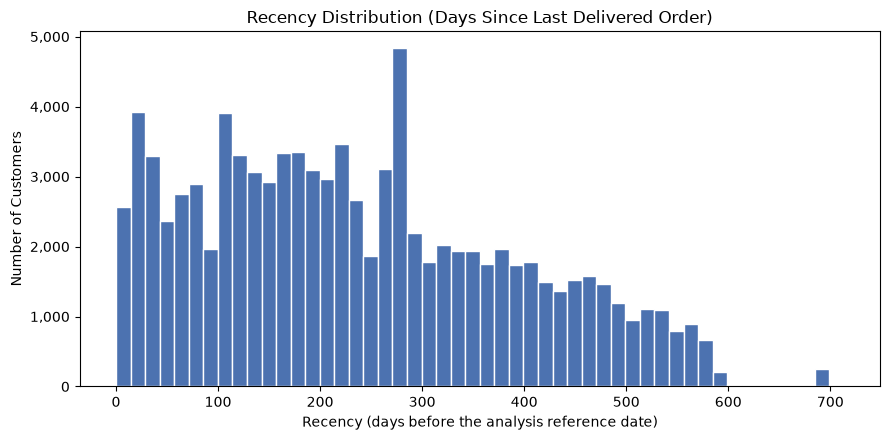

,recency_days (days)
count,93358.000000
mean,236.941773
std,152.591453
min,0.000000
25%,113.000000
50%,218.000000
75%,345.000000
max,713.000000


In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rfm["recency_days"], bins=50, color="#4C72B0", edgecolor="white")
ax.set_title("Recency Distribution (Days Since Last Delivered Order)")
ax.set_xlabel("Recency (days before the analysis reference date)")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

display(rfm["recency_days"].describe().rename("recency_days (days)").to_frame())

### Chart 2 — Frequency Distribution

Frequency is a small set of discrete integers (Section 8 showed it is extremely skewed --
the large majority of customers placed exactly one delivered order), so a bar chart of exact
value counts is more readable than a fine-grained histogram. A log-scaled y-axis is used so the
much smaller repeat-customer bars remain visible next to the dominant single-order bar.

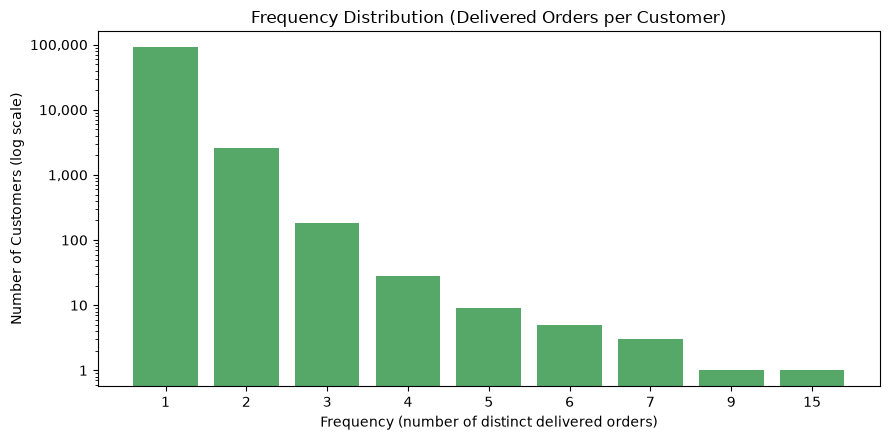

Customers with frequency == 1: 90,557 (97.0% of all RFM customers)


In [15]:
frequency_counts = rfm["frequency"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(frequency_counts.index.astype(str), frequency_counts.values, color="#55A868")
ax.set_title("Frequency Distribution (Delivered Orders per Customer)")
ax.set_xlabel("Frequency (number of distinct delivered orders)")
ax.set_ylabel("Number of Customers (log scale)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

pct_single_order = round(frequency_counts.iloc[0] / frequency_counts.sum() * 100, 2)
print(f"Customers with frequency == {frequency_counts.index[0]}: {frequency_counts.iloc[0]:,} ({pct_single_order}% of all RFM customers)")

### Chart 3 — Monetary Distribution

Like the Week 2 order-value chart, Monetary is heavily right-skewed (most customers spend a
modest amount; a small number spend a great deal). The x-axis view is clipped to the 99th
percentile of the actual `monetary` data (a data-driven cutoff, not a hard-coded value) purely
for readability -- every customer is still counted in the histogram bins, only the visible axis
range is limited.

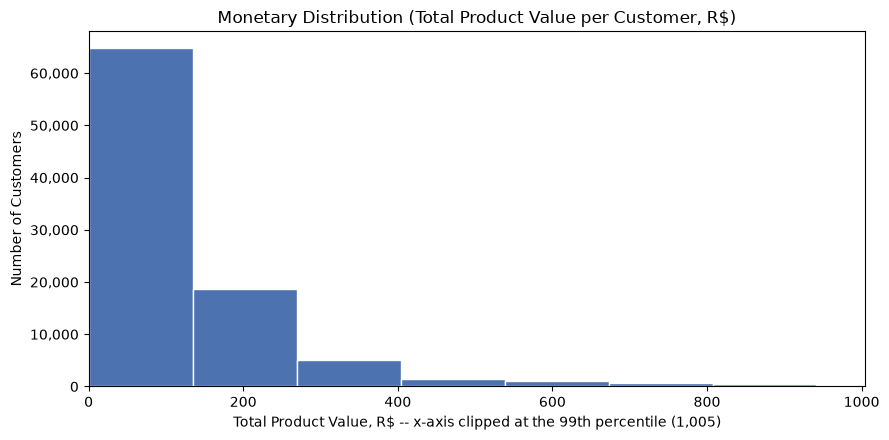

Customers beyond the 99th-percentile x-axis view limit (still counted in the bins): 929


,monetary (R$)
count,93358.000000
mean,141.621480
std,215.694014
min,0.850000
25%,47.650000
50%,89.730000
75%,154.737500
max,13440.000000


In [16]:
monetary_p99 = rfm["monetary"].quantile(0.99)
n_beyond_p99 = int((rfm["monetary"] > monetary_p99).sum())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rfm["monetary"], bins=100, color="#4C72B0", edgecolor="white")
ax.set_xlim(0, monetary_p99)
ax.set_title("Monetary Distribution (Total Product Value per Customer, R$)")
ax.set_xlabel(f"Total Product Value, R$ -- x-axis clipped at the 99th percentile ({monetary_p99:,.0f})")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Customers beyond the 99th-percentile x-axis view limit (still counted in the bins): {n_beyond_p99:,}")
display(rfm["monetary"].describe().rename("monetary (R$)").to_frame())

### Chart 4 — RFM Score Distribution

Bar chart of the most common `rfm_score` string combinations.

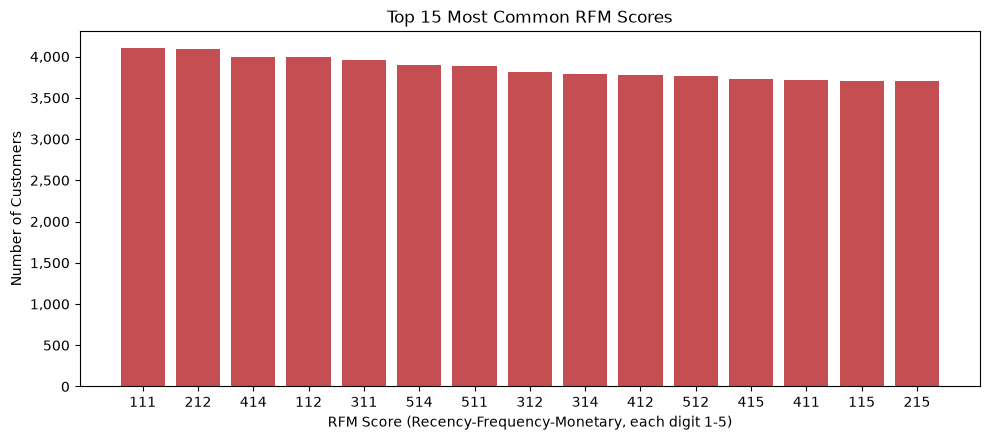

Most common single rfm_score: '111' with 4,105 customers


In [17]:
top_n_scores = 15
top_rfm_scores = rfm["rfm_score"].value_counts().sort_values(ascending=False).head(top_n_scores)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(top_rfm_scores.index, top_rfm_scores.values, color="#C44E52")
ax.set_title(f"Top {top_n_scores} Most Common RFM Scores")
ax.set_xlabel("RFM Score (Recency-Frequency-Monetary, each digit 1-5)")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"Most common single rfm_score: '{top_rfm_scores.idxmax()}' with {int(top_rfm_scores.max()):,} customers")

### Chart 5 — Customer Value Relationship (Frequency vs. Monetary)

Scatter plot of raw Frequency vs. raw Monetary. Transparency (`alpha`) is used because many
points overlap at low frequency values.

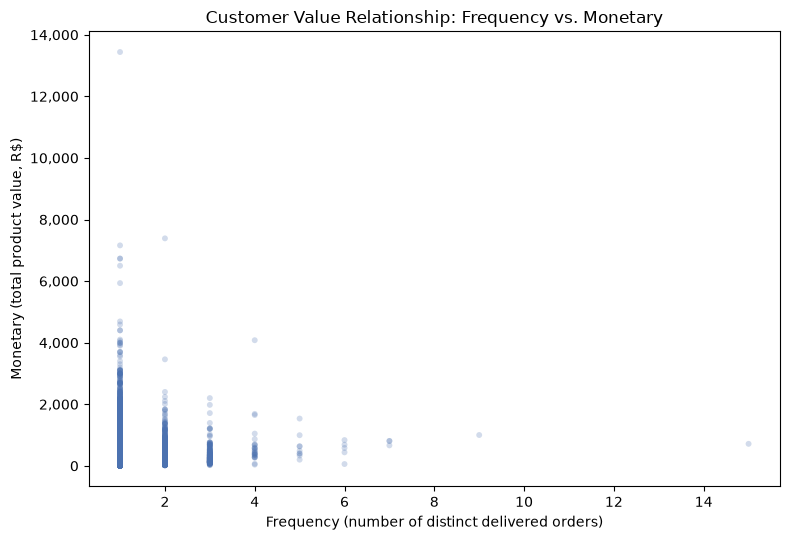

In [18]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(rfm["frequency"], rfm["monetary"], alpha=0.25, s=18, color="#4C72B0", edgecolor="none")
ax.set_title("Customer Value Relationship: Frequency vs. Monetary")
ax.set_xlabel("Frequency (number of distinct delivered orders)")
ax.set_ylabel("Monetary (total product value, R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### Chart 6 — Recency vs. Monetary

Scatter plot of Recency (days) vs. Monetary (R$), to visually check whether higher-spending
customers also tend to be more recently active.

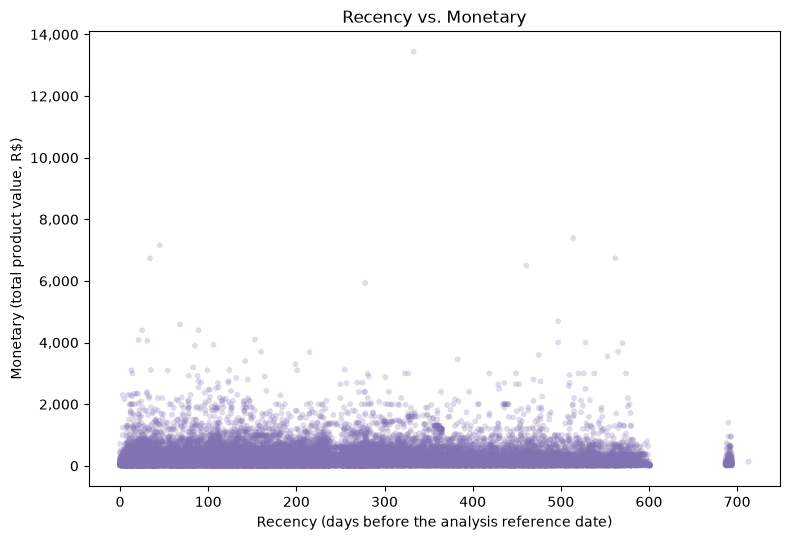

In [19]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(rfm["recency_days"], rfm["monetary"], alpha=0.25, s=18, color="#8172B2", edgecolor="none")
ax.set_title("Recency vs. Monetary")
ax.set_xlabel("Recency (days before the analysis reference date)")
ax.set_ylabel("Monetary (total product value, R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 11. RFM Summary Tables

### RFM Descriptive Statistics

In [20]:
descriptive_stats = rfm[["recency_days", "frequency", "monetary"]].describe(percentiles=[0.25, 0.5, 0.75]).T
descriptive_stats = descriptive_stats.rename(columns={"50%": "median"})
display(descriptive_stats)

,count,mean,std,min,25%,median,75%,max
recency_days,93358.0,236.941773,152.591453,0.00,113.00,218.00,345.0000,713.0
frequency,93358.0,1.033420,0.209097,1.00,1.00,1.00,1.0000,15.0
monetary,93358.0,141.621480,215.694014,0.85,47.65,89.73,154.7375,13440.0


### RFM Score Distribution (Counts and Percentages)

In [21]:
score_distribution_rows = []
for score_col in ["recency_score", "frequency_score", "monetary_score"]:
    counts = rfm[score_col].value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    for score_value in counts.index:
        score_distribution_rows.append({
            "score_type": score_col,
            "score_value": score_value,
            "customer_count": int(counts[score_value]),
            "pct_of_customers": pct[score_value],
        })

score_distribution = pd.DataFrame(score_distribution_rows)
display(score_distribution)

,score_type,score_value,customer_count,pct_of_customers
0,recency_score,1,18639,19.97
1,recency_score,2,18577,19.90
2,recency_score,3,18709,20.04
3,recency_score,4,18705,20.04
4,recency_score,5,18728,20.06
5,frequency_score,1,93130,99.76
6,frequency_score,2,209,0.22
7,frequency_score,3,9,0.01
8,frequency_score,4,8,0.01
9,frequency_score,5,2,0.00


### Top Customers by Monetary Value

Only the customer identifier (`customer_unique_id`, an anonymized hashed ID -- not a name or
any other personal identifier) and RFM metrics are shown.

In [22]:
top_n_customers = 10
top_customers = (
    rfm.sort_values("monetary", ascending=False)
    .loc[:, ["customer_unique_id", "frequency", "recency_days", "monetary"]]
    .head(top_n_customers)
    .reset_index(drop=True)
)
display(top_customers)

,customer_unique_id,frequency,recency_days,monetary
0,0a0a92112bd4c708ca5fde585afaa872,1,333,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,2,514,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,1,45,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,1,562,6735.0
4,459bef486812aa25204be022145caa62,1,34,6729.0
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,461,6499.0
6,4007669dec559734d6f53e029e360987,1,278,5934.6
7,eebb5dda148d3893cdaf5b5ca3040ccb,1,497,4690.0
8,48e1ac109decbb87765a3eade6854098,1,68,4590.0
9,a229eba70ec1c2abef51f04987deb7a5,1,89,4400.0


## 12. Export Output Files

- The validated, one-row-per-`customer_unique_id` RFM dataset is exported to
  `data/processed/olist_customer_rfm.csv`.
- Aggregated RFM summary statistics are exported to `data/output/week3_rfm_summary.csv`.

`data/raw/` is never written to, and the Week 2 cleaned extract file is left untouched.

In [23]:
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Re-verify grain immediately before export.
assert bool(rfm["customer_unique_id"].is_unique), "customer_unique_id is not unique -- refusing to export!"

rfm_export_path = PROCESSED_DATA_DIR / "olist_customer_rfm.csv"
rfm.to_csv(rfm_export_path, index=False)

summary_export_path = OUTPUT_DATA_DIR / "week3_rfm_summary.csv"
descriptive_stats.to_csv(summary_export_path)

print("Pre-export checks:")
print(f"  customer_unique_id unique: {bool(rfm['customer_unique_id'].is_unique)}")
print(f"  rows: {len(rfm):,} | columns: {rfm.shape[1]}")
print()
print(f"RFM dataset exported to:     {rfm_export_path.resolve()}")
print(f"  exists: {rfm_export_path.exists()} | size: {rfm_export_path.stat().st_size:,} bytes")
print(f"RFM summary exported to:     {summary_export_path.resolve()}")
print(f"  exists: {summary_export_path.exists()} | size: {summary_export_path.stat().st_size:,} bytes")

Pre-export checks:
  customer_unique_id unique: True
  rows: 93,358 | columns: 12

RFM dataset exported to:     /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/processed/olist_customer_rfm.csv
  exists: True | size: 8,535,654 bytes
RFM summary exported to:     /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/output/week3_rfm_summary.csv
  exists: True | size: 292 bytes


## Week 3 Findings

Findings below are computed directly from `rfm` / `rfm_orders` above -- no invented
interpretations.

In [24]:
findings = []

findings.append({
    "finding": "RFM-eligible population",
    "evidence": (
        f"{delivered_orders:,} of {total_orders:,} orders ({pct_delivered}%) have order_status == 'delivered' "
        f"and were used for RFM; the remaining {non_delivered_orders:,} orders ({round(100 - pct_delivered, 2)}%) "
        f"were excluded from the primary RFM calculation (not deleted from the source data). These delivered "
        f"orders represent {eligible_customers:,} distinct customers (by customer_unique_id)."
    ),
})

findings.append({
    "finding": "Analysis reference date",
    "evidence": (
        f"reference_date = {reference_date} (the maximum order_purchase_timestamp among delivered orders). "
        f"All recency_days values are measured backward from this fixed point."
    ),
})

findings.append({
    "finding": "Recency profile",
    "evidence": (
        f"recency_days ranges from {recency_min:,} to {recency_max:,} days, with a median of "
        f"{rfm['recency_days'].median():,.0f} days and a mean of {rfm['recency_days'].mean():,.1f} days. "
        f"The mean exceeding the median indicates a right-skewed recency distribution -- most customers' "
        f"last purchase is not extremely old, but a tail of customers has gone a long time without a "
        f"delivered order."
    ),
})

findings.append({
    "finding": "Frequency profile: single-purchase-dominated customer base",
    "evidence": (
        f"frequency ranges from {freq_min:,} to {freq_max:,} delivered orders per customer, but "
        f"{int((rfm['frequency'] == 1).sum()):,} of {len(rfm):,} customers ({round((rfm['frequency'] == 1).mean() * 100, 2)}%) "
        f"placed exactly one delivered order in the observed period. This severe skew is why a plain 5-bin "
        f"qcut on frequency was not possible (Section 8) and a value-level quantile fallback was required."
    ),
})

findings.append({
    "finding": "Monetary profile",
    "evidence": (
        f"monetary (total delivered product value per customer) ranges from R$ {mon_min:,.2f} to "
        f"R$ {mon_max:,.2f}, with a median of R$ {rfm['monetary'].median():,.2f} and a mean of "
        f"R$ {rfm['monetary'].mean():,.2f} -- the mean well above the median confirms a right-skewed spend "
        f"distribution, consistent with the Week 2 order-value finding."
    ),
})

findings.append({
    "finding": "RFM score concentration",
    "evidence": (
        f"{rfm['rfm_score'].nunique()} distinct rfm_score combinations occur out of a possible 125 (5x5x5). "
        f"The single most common combination, '{top_rfm_scores.idxmax()}', accounts for "
        f"{int(top_rfm_scores.max()):,} customers ({round(top_rfm_scores.max() / len(rfm) * 100, 2)}%) -- "
        f"consistent with the low-frequency, low-monetary concentration described above."
    ),
})

findings_df = pd.DataFrame(findings)[["finding", "evidence"]]
display(findings_df)

,finding,evidence
0,RFM-eligible population,"96,478 of 99,441 orders (97.02%) have order_st..."
1,Analysis reference date,reference_date = 2018-08-29 15:00:37 (the maxi...
2,Recency profile,"recency_days ranges from 0 to 713 days, with a..."
3,Frequency profile: single-purchase-dominated c...,frequency ranges from 1 to 15 delivered orders...
4,Monetary profile,monetary (total delivered product value per cu...
5,RFM score concentration,53 distinct rfm_score combinations occur out o...


## Week 3 Summary

**What was completed:**
- Loaded and structurally verified the Week 2 order-level extract (no raw tables reloaded).
- Inspected real `order_status` values and defined an explicit `is_rfm_eligible` flag
  (`order_status == "delivered"`) without deleting any other status from the source data.
- Derived a data-driven `reference_date` (max purchase timestamp among eligible orders) for
  Recency -- never today's date.
- Computed customer-level Recency, Frequency, and Monetary, grouped by `customer_unique_id`
  (never `customer_id`), with Frequency counting distinct `order_id` values and Monetary
  summing `total_product_value` (plus documented optional freight-inclusive supporting
  metrics).
- Ran a full validation suite (uniqueness, non-negativity, and monetary/frequency
  reconciliation back to `rfm_orders`) -- all checks passed.
- Built quintile-based `recency_score`, `frequency_score`, `monetary_score` (1-5), with a
  documented, transparent fallback for the tie-heavy Frequency metric, plus a combined
  `rfm_score` string and a clearly-caveated `rfm_score_numeric`.
- Produced six labeled visualizations and summary tables (descriptive stats, score
  distribution, top customers by Monetary).

**Output file created:** `data/processed/olist_customer_rfm.csv` — one row per
`customer_unique_id`, validated. A supporting aggregate file was also written to
`data/output/week3_rfm_summary.csv`.

**Validation status:** all Section 7 validation checks (`validation_summary`) passed with
0 failures; all three scores confirmed within the documented 1-5 range.

**How this supports Week 4 (CLV):** Week 4 will build historical/predictive Customer Lifetime
Value directly on top of this customer-level RFM dataset -- Frequency and Monetary here are
exactly the purchase-count and spend building blocks a CLV calculation needs, and Recency will
help characterize customer activity/churn risk. No CLV, segmentation labels, predictive
modeling, or Tableau dashboard work was performed in this notebook, per the Week 3 scope.

## 13. Geographic Analysis — Customer and Seller States

The RFM analysis above (Sections 1-12) is complete, validated, and **unchanged** below this
point. This section adds the faculty's remaining Week 3 geographic requirements:

- **R2** — a state-level distance map (customer state ↔ seller state)
- **R3** — an interactive distance-vs-delivery-delay analysis with tooltips

**Why `customer_unique_id` remains the RFM identifier:** nothing here recalculates or
redefines RFM. `customer_unique_id` (Section 1) is still the correct real-customer identifier
for RFM and continues to be carried through the geographic dataset purely as a reference
column — it is never used as a grouping key for distance/delay, which are inherently
**order-item (shipment)** concepts, not customer concepts.

**Why the geographic analysis uses a separate, shipment-level dataset:** `olist_customer_rfm.csv`
is fixed at one row per `customer_unique_id` (Section 6-7) and must stay that way. Distance and
delivery delay, however, are properties of an individual **shipment** — a single `order_item`
traveling from one seller to one customer for one order. An order with items from two different
sellers has two different seller locations and, in principle, two different shipment distances.
Forcing that into the customer-level RFM table would either (a) silently pick one seller
arbitrarily, or (b) duplicate every RFM row per shipment, corrupting the customer-level grain
Section 7 validated. Instead, a new, explicitly-named analytical dataset — one row per
**order-item shipment** — is built from scratch for this section only, and `olist_customer_rfm.csv`
is not read, modified, or re-exported anywhere below.

### 13.1 Load Geographic Source Tables

Only the raw tables that are genuinely not already available are loaded here:

- `olist_geolocation_dataset.csv` — needed for ZIP-prefix coordinates (not in Week 2 extract at all).
- `olist_sellers_dataset.csv` — needed for seller ZIP/state (Week 2 extract has no seller location).
- `olist_order_items_dataset.csv` — needed for the **per-item `seller_id`** (Week 2 aggregated
  this away into `total_order_items` / `distinct_sellers`; the individual item-to-seller
  mapping only exists in the raw table).

`olist_customers_dataset.csv` is **not** reloaded: the already-loaded `order_level` dataframe
(Section 2) already carries `customer_unique_id`, `customer_zip_code_prefix`, and
`customer_state` for every order, so re-reading the raw customers table would only add
duplication risk without adding information — the same principle Week 2 applied when it chose
not to reload tables it could already aggregate from what was on hand.

A byte-level checksum of each raw file loaded here is recorded now, to be re-checked in Section
16 as direct proof that `data/raw/` was never modified by this notebook.

In [25]:
import hashlib
import plotly.graph_objects as go

RAW_DATA_DIR = Path("../data/raw")

def file_md5(path):
    with open(path, "rb") as fh:
        return hashlib.md5(fh.read()).hexdigest()

geo_source_files = {
    "geolocation": RAW_DATA_DIR / "olist_geolocation_dataset.csv",
    "sellers": RAW_DATA_DIR / "olist_sellers_dataset.csv",
    "order_items": RAW_DATA_DIR / "olist_order_items_dataset.csv",
}

raw_file_checksums_before = {name: file_md5(path) for name, path in geo_source_files.items()}

geolocation_raw = pd.read_csv(geo_source_files["geolocation"])
sellers_raw = pd.read_csv(geo_source_files["sellers"])
order_items_raw = pd.read_csv(geo_source_files["order_items"])

for name, df in [("geolocation_raw", geolocation_raw), ("sellers_raw", sellers_raw), ("order_items_raw", order_items_raw)]:
    print(f"Loaded '{name}': {df.shape[0]:>9,} rows x {df.shape[1]:>2} columns")


Loaded 'geolocation_raw': 1,000,163 rows x  5 columns
Loaded 'sellers_raw':     3,095 rows x  4 columns
Loaded 'order_items_raw':   112,650 rows x  7 columns


### 13.2 Build ZIP-prefix Geolocation Lookup

**Why aggregation is required before any join:** Week 1's audit already established that
`geolocation_zip_code_prefix` is **not** a unique key — `olist_geolocation_dataset.csv` has
~1,000,000 rows collapsing to only ~19,000 distinct ZIP prefixes (repeated GPS pings at slightly
different lat/lng per prefix). Joining `customers`/`sellers` directly to raw `geolocation` on ZIP
prefix would multiply every matched row by however many geolocation pings share that prefix —
exactly the row-multiplication risk this section must avoid. A ZIP-prefix lookup with **one row
per prefix** is therefore built first.

**Data-quality step (documented, not silent):** a small number of raw geolocation rows have
latitude/longitude far outside Brazil's territory (a known artifact of this public dataset —
e.g. a mis-recorded sign or digit). These are excluded from the aggregation using an
approximate Brazil bounding box, so they cannot pull a ZIP prefix's representative coordinate
off into the ocean or another continent. The excluded count is reported below, and this filter
is applied **only** to the geolocation lookup, not to any other table.

**Representative value per ZIP prefix:** `latitude`/`longitude` use the **median** (robust to
the occasional remaining outlier ping), and a `geo_modal_state` is also derived using the
**mode** (most frequent) `geolocation_state` value for that prefix, exactly as the assignment
brief suggests. `geo_modal_state` is retained only as an **audit/cross-check** field — the
authoritative `customer_state` / `seller_state` used everywhere else in this section come
directly from the (already clean, single-value-per-record) `customers` / `sellers` tables, not
from this derived field.

In [26]:
# Approximate Brazil bounding box (mainland + islands) -- used only to catch clearly-erroneous
# geolocation pings before they corrupt a ZIP prefix's median coordinate.
BRAZIL_LAT_MIN, BRAZIL_LAT_MAX = -34.0, 5.5
BRAZIL_LON_MIN, BRAZIL_LON_MAX = -74.5, -34.0

within_brazil_bbox = (
    geolocation_raw["geolocation_lat"].between(BRAZIL_LAT_MIN, BRAZIL_LAT_MAX)
    & geolocation_raw["geolocation_lng"].between(BRAZIL_LON_MIN, BRAZIL_LON_MAX)
)
n_outside_bbox = int((~within_brazil_bbox).sum())
n_zip_prefixes_affected = int(geolocation_raw.loc[~within_brazil_bbox, "geolocation_zip_code_prefix"].nunique())

print(f"geolocation rows outside Brazil's approximate bounding box (excluded, documented): {n_outside_bbox:,} of {len(geolocation_raw):,}")
print(f"distinct ZIP prefixes with at least one such row: {n_zip_prefixes_affected:,}")

geolocation_clean = geolocation_raw.loc[within_brazil_bbox].copy()

zip_geo_lookup = (
    geolocation_clean.groupby("geolocation_zip_code_prefix")
    .agg(
        latitude=("geolocation_lat", "median"),
        longitude=("geolocation_lng", "median"),
        geo_modal_state=("geolocation_state", lambda s: s.mode().iat[0]),
    )
    .reset_index()
)

zip_lookup_unique = bool(zip_geo_lookup["geolocation_zip_code_prefix"].is_unique)
assert zip_lookup_unique, "zip_geo_lookup must have exactly one row per ZIP prefix!"

print(f"\nzip_geo_lookup: {len(zip_geo_lookup):,} rows (one per distinct, in-bounds ZIP prefix)")
print(f"  reduced from {len(geolocation_raw):,} raw geolocation rows -- ZIP-prefix uniqueness confirmed: {zip_lookup_unique}")
display(zip_geo_lookup.head())


geolocation rows outside Brazil's approximate bounding box (excluded, documented): 42 of 1,000,163
distinct ZIP prefixes with at least one such row: 21



zip_geo_lookup: 19,010 rows (one per distinct, in-bounds ZIP prefix)
  reduced from 1,000,163 raw geolocation rows -- ZIP-prefix uniqueness confirmed: True


,geolocation_zip_code_prefix,latitude,longitude,geo_modal_state
0,1001,-23.550381,-46.634027,SP
1,1002,-23.548551,-46.635072,SP
2,1003,-23.548977,-46.635313,SP
3,1004,-23.549535,-46.634771,SP
4,1005,-23.549612,-46.636532,SP


### 13.3 Map Customer Locations

Customer geographic coordinates are mapped at the **order** grain (one row per `order_id`,
matching `order_level`), not deduplicated to one row per `customer_unique_id` — a customer can
place different orders from different ZIP codes, so a shipment's true origin/destination must
use *that order's own* `customer_zip_code_prefix`, not an arbitrary "representative" address
for the customer.

`customer_state` is carried through as-is from `order_level` (ultimately sourced from the raw
`customers` table via the Week 2 join) — it is **not** overwritten by `geo_modal_state`.

In [27]:
customer_location_fields = [
    "order_id", "customer_unique_id", "customer_zip_code_prefix", "customer_state",
    "order_status", "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date",
]
customer_locations = (
    order_level[customer_location_fields]
    .merge(zip_geo_lookup, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
    .drop(columns=["geolocation_zip_code_prefix"])
    .rename(columns={
        "latitude": "customer_latitude",
        "longitude": "customer_longitude",
        "geo_modal_state": "customer_geo_modal_state",
    })
)

assert len(customer_locations) == len(order_level), "customer_locations must preserve the order_level row count exactly!"

n_customer_rows_matched = int(customer_locations["customer_latitude"].notna().sum())
n_customer_rows_unmatched = len(customer_locations) - n_customer_rows_matched
n_customer_zip_distinct = int(order_level["customer_zip_code_prefix"].nunique())
n_customer_zip_matched = int(
    pd.Series(order_level["customer_zip_code_prefix"].unique()).isin(zip_geo_lookup["geolocation_zip_code_prefix"]).sum()
)

print(f"customer_locations: {len(customer_locations):,} rows (one per order_id, matches order_level)")
print(f"orders with a matched customer coordinate: {n_customer_rows_matched:,} ({round(n_customer_rows_matched / len(customer_locations) * 100, 3)}%)")
print(f"orders with NO matched customer coordinate: {n_customer_rows_unmatched:,} ({round(n_customer_rows_unmatched / len(customer_locations) * 100, 3)}%)")
print(f"distinct customer ZIP prefixes: {n_customer_zip_distinct:,} | matched: {n_customer_zip_matched:,} | unmatched: {n_customer_zip_distinct - n_customer_zip_matched:,}")


customer_locations: 99,441 rows (one per order_id, matches order_level)
orders with a matched customer coordinate: 99,162 (99.719%)
orders with NO matched customer coordinate: 279 (0.281%)
distinct customer ZIP prefixes: 14,994 | matched: 14,836 | unmatched: 158


### 13.4 Map Seller Locations

Sellers are mapped at the **seller** grain (one row per `seller_id`, matching the raw `sellers`
table) using the same ZIP-prefix lookup.

In [28]:
seller_locations = (
    sellers_raw.merge(zip_geo_lookup, left_on="seller_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="left")
    .drop(columns=["geolocation_zip_code_prefix"])
    .rename(columns={
        "latitude": "seller_latitude",
        "longitude": "seller_longitude",
        "geo_modal_state": "seller_geo_modal_state",
    })
)

assert len(seller_locations) == len(sellers_raw), "seller_locations must preserve the sellers_raw row count exactly!"
assert bool(seller_locations["seller_id"].is_unique), "seller_locations must have exactly one row per seller_id!"

n_seller_rows_matched = int(seller_locations["seller_latitude"].notna().sum())
n_seller_rows_unmatched = len(seller_locations) - n_seller_rows_matched
n_seller_zip_distinct = int(sellers_raw["seller_zip_code_prefix"].nunique())
n_seller_zip_matched = int(pd.Series(sellers_raw["seller_zip_code_prefix"].unique()).isin(zip_geo_lookup["geolocation_zip_code_prefix"]).sum())

print(f"seller_locations: {len(seller_locations):,} rows (one per seller_id, matches sellers_raw)")
print(f"sellers with a matched coordinate: {n_seller_rows_matched:,} ({round(n_seller_rows_matched / len(seller_locations) * 100, 3)}%)")
print(f"sellers with NO matched coordinate: {n_seller_rows_unmatched:,} ({round(n_seller_rows_unmatched / len(seller_locations) * 100, 3)}%)")
print(f"distinct seller ZIP prefixes: {n_seller_zip_distinct:,} | matched: {n_seller_zip_matched:,} | unmatched: {n_seller_zip_distinct - n_seller_zip_matched:,}")


seller_locations: 3,095 rows (one per seller_id, matches sellers_raw)
sellers with a matched coordinate: 3,088 (99.774%)
sellers with NO matched coordinate: 7 (0.226%)
distinct seller ZIP prefixes: 2,246 | matched: 2,239 | unmatched: 7


### 13.5 Geographic Matching Audit

A consolidated report of ZIP-prefix matching coverage for both sides, plus an audit
cross-check comparing each canonical `customer_state` against the ZIP-derived
`customer_geo_modal_state` (where both are available) — purely to sanity-check the lookup, not
to override the canonical state.

In [29]:
geo_matching_audit = pd.DataFrame([
    {
        "side": "customer",
        "distinct_zip_prefixes": n_customer_zip_distinct,
        "zip_prefixes_matched": n_customer_zip_matched,
        "zip_prefixes_unmatched": n_customer_zip_distinct - n_customer_zip_matched,
        "pct_zip_unmatched": round((n_customer_zip_distinct - n_customer_zip_matched) / n_customer_zip_distinct * 100, 3),
        "records_matched": n_customer_rows_matched,
        "records_unmatched": n_customer_rows_unmatched,
        "pct_records_unmatched": round(n_customer_rows_unmatched / len(customer_locations) * 100, 3),
    },
    {
        "side": "seller",
        "distinct_zip_prefixes": n_seller_zip_distinct,
        "zip_prefixes_matched": n_seller_zip_matched,
        "zip_prefixes_unmatched": n_seller_zip_distinct - n_seller_zip_matched,
        "pct_zip_unmatched": round((n_seller_zip_distinct - n_seller_zip_matched) / n_seller_zip_distinct * 100, 3),
        "records_matched": n_seller_rows_matched,
        "records_unmatched": n_seller_rows_unmatched,
        "pct_records_unmatched": round(n_seller_rows_unmatched / len(seller_locations) * 100, 3),
    },
])
display(geo_matching_audit)

# Cross-check: canonical state vs. ZIP-derived modal state (audit only -- canonical state is
# always the one actually used downstream).
customer_state_comparable = customer_locations.dropna(subset=["customer_geo_modal_state"])
customer_state_agreement = (customer_state_comparable["customer_state"] == customer_state_comparable["customer_geo_modal_state"]).mean()
seller_state_comparable = seller_locations.dropna(subset=["seller_geo_modal_state"])
seller_state_agreement = (seller_state_comparable["seller_state"] == seller_state_comparable["seller_geo_modal_state"]).mean()

print(f"\nCanonical vs. ZIP-derived state agreement (audit only): customers {customer_state_agreement * 100:.2f}%, sellers {seller_state_agreement * 100:.2f}%")


,side,distinct_zip_prefixes,zip_prefixes_matched,zip_prefixes_unmatched,pct_zip_unmatched,records_matched,records_unmatched,pct_records_unmatched
0,customer,14994,14836,158,1.054,99162,279,0.281
1,seller,2246,2239,7,0.312,3088,7,0.226



Canonical vs. ZIP-derived state agreement (audit only): customers 100.00%, sellers 98.87%


### 13.6 Calculate Customer-Seller Distance

**Analytical grain:** one row per **order-item shipment** (`order_id` + `order_item_id`),
matching raw `order_items` exactly — this is the shipment-level dataset referenced in Section
13's introduction.

**Why Haversine, not Euclidean:** latitude/longitude are angular coordinates on a sphere, not a
flat Cartesian plane — treating them as `sqrt(Δlat² + Δlon²)` (Euclidean) badly distorts real
distances, especially across Brazil's ~38° span of latitude (a degree of longitude covers far
less ground near the poles than at the equator, and Euclidean distance ignores this entirely).
The **Haversine formula** instead computes the great-circle distance between two points on a
sphere from their latitude/longitude, using Earth's mean radius (6,371.0088 km), and returns a
result directly in kilometers.

In [30]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometers between two (lat, lon) points, in decimal degrees,
    using the Haversine formula. Vectorized -- accepts pandas Series/NumPy arrays."""
    EARTH_RADIUS_KM = 6371.0088
    lat1_r, lon1_r, lat2_r, lon2_r = (np.radians(v) for v in (lat1, lon1, lat2, lon2))
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon / 2) ** 2
    return EARTH_RADIUS_KM * 2 * np.arcsin(np.sqrt(a))


seller_geo_fields = ["seller_id", "seller_zip_code_prefix", "seller_state", "seller_latitude", "seller_longitude"]
shipment_geo = (
    order_items_raw[["order_id", "order_item_id", "seller_id"]]
    .merge(customer_locations, on="order_id", how="left")
    .merge(seller_locations[seller_geo_fields], on="seller_id", how="left")
)

assert len(shipment_geo) == len(order_items_raw), "shipment_geo must preserve the order_items_raw row count exactly (no fan-out)!"

shipment_geo["has_both_coords"] = (
    shipment_geo[["customer_latitude", "customer_longitude", "seller_latitude", "seller_longitude"]].notna().all(axis=1)
)

shipment_geo["distance_km"] = np.nan
shipment_geo.loc[shipment_geo["has_both_coords"], "distance_km"] = haversine_distance_km(
    shipment_geo.loc[shipment_geo["has_both_coords"], "customer_latitude"],
    shipment_geo.loc[shipment_geo["has_both_coords"], "customer_longitude"],
    shipment_geo.loc[shipment_geo["has_both_coords"], "seller_latitude"],
    shipment_geo.loc[shipment_geo["has_both_coords"], "seller_longitude"],
)

n_shipments = len(shipment_geo)
n_with_distance = int(shipment_geo["distance_km"].notna().sum())
n_missing_customer_coord = int(shipment_geo["customer_latitude"].isna().sum())
n_missing_seller_coord = int(shipment_geo["seller_latitude"].isna().sum())

print(f"shipment_geo: {n_shipments:,} rows (one per order_item -- matches order_items_raw)")
print(f"shipments with a calculable distance_km: {n_with_distance:,} ({round(n_with_distance / n_shipments * 100, 2)}%)")
print(f"shipments missing a customer coordinate: {n_missing_customer_coord:,}")
print(f"shipments missing a seller coordinate:   {n_missing_seller_coord:,}")
print(f"\ndistance_km is never negative: {bool((shipment_geo['distance_km'].dropna() >= 0).all())}")
display(shipment_geo["distance_km"].describe().rename("distance_km").to_frame())


shipment_geo: 112,650 rows (one per order_item -- matches order_items_raw)
shipments with a calculable distance_km: 112,095 (99.51%)
shipments missing a customer coordinate: 303
shipments missing a seller coordinate:   253

distance_km is never negative: True


,distance_km
count,112095.000000
mean,596.649332
std,588.843688
min,0.000000
25%,183.090316
50%,431.715351
75%,791.783265
max,3579.344628


### 13.7 Delivery Delay for Geographic Analysis

**Consistent with the Week 1 definition** (`01_week1_data_audit.ipynb`, Delivery Delay Audit
section) — not redefined here:

    delivery_delay_days = order_delivered_customer_date - order_estimated_delivery_date

computed in **fractional days** (`.dt.total_seconds() / 86400`), only where both dates are
present. Positive = delivered late, negative = delivered early, zero = exactly on time. (This
intentionally differs from the RFM `recency_days` column above, which uses whole/integer days
by the Week 3 RFM specification — the two are different metrics for different purposes, both
documented explicitly where they are defined.)

An `is_delivered_order` flag (`order_status == "delivered"`) is added for this section,
mirroring the same eligibility rule as the RFM `is_rfm_eligible` flag (Section 4) — canceled/
unavailable/unfulfilled orders are never treated as having a real delivery date.

In [31]:
shipment_geo["order_delivered_customer_date"] = pd.to_datetime(shipment_geo["order_delivered_customer_date"])
shipment_geo["order_estimated_delivery_date"] = pd.to_datetime(shipment_geo["order_estimated_delivery_date"])
shipment_geo["is_delivered_order"] = shipment_geo["order_status"] == "delivered"

shipment_geo["has_both_dates"] = (
    shipment_geo["order_delivered_customer_date"].notna() & shipment_geo["order_estimated_delivery_date"].notna()
)
shipment_geo["delivery_delay_days"] = np.nan
shipment_geo.loc[shipment_geo["has_both_dates"], "delivery_delay_days"] = (
    shipment_geo.loc[shipment_geo["has_both_dates"], "order_delivered_customer_date"]
    - shipment_geo.loc[shipment_geo["has_both_dates"], "order_estimated_delivery_date"]
).dt.total_seconds() / 86400

n_delivered_shipments = int(shipment_geo["is_delivered_order"].sum())
n_non_delivered_shipments = n_shipments - n_delivered_shipments
n_delivered_with_delay = int((shipment_geo["is_delivered_order"] & shipment_geo["delivery_delay_days"].notna()).sum())
n_non_delivered_with_dates = int((~shipment_geo["is_delivered_order"] & shipment_geo["has_both_dates"]).sum())

print(f"Delivered shipments:                                {n_delivered_shipments:,}")
print(f"Non-delivered shipments (excluded from delay stats): {n_non_delivered_shipments:,}")
print(f"Delivered shipments with a calculable delivery_delay_days: {n_delivered_with_delay:,}")
print(f"Non-delivered shipments that happen to have both dates (NOT used as delay observations): {n_non_delivered_with_dates:,}")

display(
    shipment_geo.loc[shipment_geo["is_delivered_order"], "delivery_delay_days"]
    .describe()
    .rename("delivery_delay_days (delivered shipments only)")
    .to_frame()
)


Delivered shipments:                                110,197
Non-delivered shipments (excluded from delay stats): 2,453
Delivered shipments with a calculable delivery_delay_days: 110,189
Non-delivered shipments that happen to have both dates (NOT used as delay observations): 7


,delivery_delay_days (delivered shipments only)
count,110189.000000
mean,-11.331987
std,10.160368
min,-146.016123
25%,-16.320440
50%,-12.046447
75%,-6.476655
max,188.975081


### 13.8 State-Level Distance Summary

Two aggregations, both built directly from `shipment_geo`:

- **`state_pair_summary`** — one row per (`customer_state`, `seller_state`) pair actually
  observed in the data. `order_count` here counts **shipment (order-item) rows**, not distinct
  orders — an order with two items shipped from the same seller's state contributes 2 to that
  pair's `order_count`. This is stated explicitly to avoid any ambiguity about grain.
  `average_delivery_delay_days` is computed **only** from delivered shipments with a valid
  delay (Section 13.7); distance statistics use all shipments with a valid `distance_km`
  regardless of order status (distance does not depend on delivery outcome).
- **`customer_state_summary`** — the same idea collapsed to one row per `customer_state`
  (dropping the seller-state split), used for the simpler per-state table in Section 15.

In [32]:
distance_by_pair = (
    shipment_geo.dropna(subset=["distance_km"])
    .groupby(["customer_state", "seller_state"])
    .agg(order_count=("order_item_id", "size"), average_distance_km=("distance_km", "mean"), median_distance_km=("distance_km", "median"))
    .reset_index()
)

delay_by_pair = (
    shipment_geo.loc[shipment_geo["is_delivered_order"]]
    .dropna(subset=["delivery_delay_days"])
    .groupby(["customer_state", "seller_state"])
    .agg(average_delivery_delay_days=("delivery_delay_days", "mean"))
    .reset_index()
)

state_pair_summary = distance_by_pair.merge(delay_by_pair, on=["customer_state", "seller_state"], how="left")
state_pair_summary = state_pair_summary.sort_values("order_count", ascending=False).reset_index(drop=True)

print(f"state_pair_summary: {len(state_pair_summary):,} distinct customer_state x seller_state pairs observed")
display(state_pair_summary.head(10))

distance_by_customer_state = (
    shipment_geo.dropna(subset=["distance_km"])
    .groupby("customer_state")
    .agg(order_count=("order_item_id", "size"), average_distance_km=("distance_km", "mean"), median_distance_km=("distance_km", "median"))
    .reset_index()
)
delay_by_customer_state = (
    shipment_geo.loc[shipment_geo["is_delivered_order"]]
    .dropna(subset=["delivery_delay_days"])
    .groupby("customer_state")
    .agg(average_delivery_delay_days=("delivery_delay_days", "mean"))
    .reset_index()
)
customer_state_summary = (
    distance_by_customer_state.merge(delay_by_customer_state, on="customer_state", how="left")
    .sort_values("order_count", ascending=False)
    .reset_index(drop=True)
)

print(f"\ncustomer_state_summary: {len(customer_state_summary):,} distinct customer states")
display(customer_state_summary)


state_pair_summary: 416 distinct customer_state x seller_state pairs observed


,customer_state,seller_state,order_count,average_distance_km,median_distance_km,average_delivery_delay_days
0,SP,SP,36136,150.823679,94.902370,-9.534247
1,RJ,SP,9661,441.942125,383.636390,-10.412993
2,MG,SP,8676,495.417344,488.937030,-12.096000
3,RS,SP,4178,907.177371,867.672231,-13.756257
4,PR,SP,3647,463.549834,420.550325,-12.505085
5,SP,PR,3403,470.364862,472.504292,-14.584176
6,SP,MG,2931,417.114564,463.902330,-12.951149
7,SC,SP,2742,564.779772,548.387251,-10.327150
8,BA,SP,2691,1391.894364,1449.357422,-10.237707
9,MG,MG,1701,260.769132,241.447897,-11.903278



customer_state_summary: 27 distinct customer states


,customer_state,order_count,average_distance_km,median_distance_km,average_delivery_delay_days
0,SP,47338,247.188459,162.960771,-10.511971
1,RJ,14523,486.861635,394.458946,-11.303516
2,MG,13087,533.573691,491.041231,-12.641385
3,RS,6215,867.959451,855.615337,-13.432036
4,PR,5715,485.292008,427.006735,-12.792034
5,SC,4167,572.721707,534.563756,-10.868302
6,BA,3777,1344.541690,1426.685953,-10.288562
7,GO,2319,775.134249,803.688366,-11.595926
8,ES,2244,799.703206,762.023208,-9.949212
9,DF,2212,829.301665,865.441869,-11.493049


## 14. R2 — State-Level Distance Map

**What this map represents:** each labeled marker is a Brazilian state's representative
geographic centroid (median latitude/longitude of all in-bounds `geolocation` pings recorded
for that state — real observed coordinates, never fabricated). Marker **color** encodes that
state's average outbound shipment distance (`average_distance_km`, from `customer_state_summary`)
and marker **size** encodes its order volume (shipment count). The lines connect
`customer_state → seller_state` for the pairs with the highest shipment volume, with line
**thickness proportional to `order_count`** (documented, not an arbitrary visual choice); full
distance/delay metrics for every pair are available on hover and in `state_pair_summary`.

Only the top pairs by volume are drawn as lines (a data-driven readability cutoff, not a
hard-coded expectation) — the complete pair matrix is exported to
`data/output/week3_state_distance_summary.csv` regardless of how many lines are drawn.

Built with **Plotly `Scattergeo`**, which draws directly on a built-in base map by latitude/
longitude — no external GeoJSON/shapefile download is required.

In [33]:
state_centroids = (
    geolocation_clean.groupby("geolocation_state")
    .agg(state_latitude=("geolocation_lat", "median"), state_longitude=("geolocation_lng", "median"))
    .reset_index()
    .rename(columns={"geolocation_state": "state"})
)

TOP_N_FLOW_PAIRS = min(40, len(state_pair_summary))
flow_pairs = state_pair_summary.sort_values("order_count", ascending=False).head(TOP_N_FLOW_PAIRS).copy()
flow_pairs = flow_pairs.merge(
    state_centroids.rename(columns={"state": "customer_state", "state_latitude": "customer_centroid_lat", "state_longitude": "customer_centroid_lon"}),
    on="customer_state", how="left",
)
flow_pairs = flow_pairs.merge(
    state_centroids.rename(columns={"state": "seller_state", "state_latitude": "seller_centroid_lat", "state_longitude": "seller_centroid_lon"}),
    on="seller_state", how="left",
)

node_data = customer_state_summary.merge(
    state_centroids.rename(columns={"state": "customer_state"}), on="customer_state", how="left"
)

max_pair_order_count = flow_pairs["order_count"].max()
max_node_order_count = node_data["order_count"].max()

fig_state_map = go.Figure()

for _, row in flow_pairs.iterrows():
    delay_text = f"{row['average_delivery_delay_days']:.2f} days" if pd.notna(row["average_delivery_delay_days"]) else "n/a (no delivered shipments)"
    fig_state_map.add_trace(go.Scattergeo(
        lon=[row["customer_centroid_lon"], row["seller_centroid_lon"]],
        lat=[row["customer_centroid_lat"], row["seller_centroid_lat"]],
        mode="lines",
        line=dict(width=1 + 5 * row["order_count"] / max_pair_order_count, color="rgba(76,114,176,0.4)"),
        hoverinfo="text",
        text=(
            f"Customer State: {row['customer_state']}<br>Seller State: {row['seller_state']}<br>"
            f"Order Count (shipments): {row['order_count']:,}<br>"
            f"Avg Distance: {row['average_distance_km']:,.0f} km<br>"
            f"Median Distance: {row['median_distance_km']:,.0f} km<br>"
            f"Avg Delivery Delay: {delay_text}"
        ),
        showlegend=False,
    ))

fig_state_map.add_trace(go.Scattergeo(
    lon=node_data["state_longitude"],
    lat=node_data["state_latitude"],
    mode="markers+text",
    text=node_data["customer_state"],
    textposition="top center",
    marker=dict(
        size=8 + 24 * node_data["order_count"] / max_node_order_count,
        color=node_data["average_distance_km"],
        colorscale="YlOrRd",
        showscale=True,
        colorbar=dict(title="Avg Distance<br>(km)"),
        line=dict(width=0.6, color="black"),
    ),
    customdata=node_data[["order_count", "average_distance_km", "median_distance_km", "average_delivery_delay_days"]].values,
    hovertemplate=(
        "Customer State: %{text}<br>"
        "Order Count (shipments): %{customdata[0]:,.0f}<br>"
        "Avg Distance: %{customdata[1]:,.0f} km<br>"
        "Median Distance: %{customdata[2]:,.0f} km<br>"
        "Avg Delivery Delay: %{customdata[3]:.2f} days<extra></extra>"
    ),
    name="Customer State",
))

fig_state_map.update_geos(
    scope="south america", resolution=50, showcountries=True, countrycolor="rgb(150,150,150)",
    showland=True, landcolor="rgb(235,235,235)", showocean=True, oceancolor="rgb(220,235,245)",
    showsubunits=True,
)
fig_state_map.update_layout(
    title=(
        f"State-Level Customer -> Seller Distance Map<br>"
        f"<sup>Top {TOP_N_FLOW_PAIRS} state-pair flows by shipment volume (line width); "
        f"marker color = avg. outbound distance, marker size = order volume</sup>"
    ),
    height=680,
    margin=dict(l=10, r=10, t=90, b=10),
)

fig_state_map.show()

state_map_output_path = OUTPUT_DATA_DIR / "week3_state_distance_map.html"
fig_state_map.write_html(state_map_output_path)
print(f"\nState-level distance map saved to: {state_map_output_path.resolve()}")
print(f"  exists: {state_map_output_path.exists()} | size: {state_map_output_path.stat().st_size:,} bytes")



State-level distance map saved to: /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/output/week3_state_distance_map.html
  exists: True | size: 4,845,333 bytes


## 15. R3 — Distance vs. Delivery-Delay Analysis

**Analytical grain:** one row per **order-item shipment** (same as `shipment_geo`, Section
13.6) — restricted to shipments belonging to **delivered** orders with both a valid
`distance_km` and a valid `delivery_delay_days`. If an order has multiple items/shipments, each
qualifying shipment appears as its own point; this is stated explicitly so the scatter plot and
correlation are not mistaken for one-point-per-order.

**Correlation indicates association, not causation.** A correlation coefficient between
distance and delivery delay, however strong or weak, would only describe how the two variables
move together across the observed shipments — it says nothing about whether distance *causes*
delay (other factors — carrier, warehouse processing time, regional logistics infrastructure,
holidays, etc. — are not controlled for here).

### 15.1 Correlation Statistics

- **Pearson** correlation measures linear association and is sensitive to outliers/skew.
- **Spearman** correlation measures monotonic (rank-based) association and is more robust to
  the skew/outliers expected in both `distance_km` and `delivery_delay_days`; it is computed
  here as the Pearson correlation of the **rank-transformed** values (a standard, well-known
  equivalence), which avoids adding `scipy` as a project dependency for a single statistic.

Interpretation uses a standard, pre-defined magnitude scale for `|r|` (not invented after
seeing the result): **0.00-0.19 very weak, 0.20-0.39 weak, 0.40-0.59 moderate, 0.60-0.79
strong, 0.80-1.00 very strong.**

In [34]:
valid_distance_delay = shipment_geo.loc[
    shipment_geo["is_delivered_order"]
    & shipment_geo["distance_km"].notna()
    & shipment_geo["delivery_delay_days"].notna()
].copy()

n_valid_observations = len(valid_distance_delay)
n_delivered_excluded_missing = n_delivered_shipments - n_valid_observations

pearson_corr = valid_distance_delay["distance_km"].corr(valid_distance_delay["delivery_delay_days"], method="pearson")

distance_rank = valid_distance_delay["distance_km"].rank()
delay_rank = valid_distance_delay["delivery_delay_days"].rank()
spearman_corr = distance_rank.corr(delay_rank, method="pearson")

def interpret_correlation_magnitude(r):
    abs_r = abs(r)
    if abs_r < 0.20:
        return "very weak"
    elif abs_r < 0.40:
        return "weak"
    elif abs_r < 0.60:
        return "moderate"
    elif abs_r < 0.80:
        return "strong"
    else:
        return "very strong"

pearson_strength = interpret_correlation_magnitude(pearson_corr)
spearman_strength = interpret_correlation_magnitude(spearman_corr)

correlation_report = pd.DataFrame([
    {"statistic": "Valid observations used", "value": f"{n_valid_observations:,}"},
    {"statistic": "Delivered shipments excluded (missing distance and/or delay)", "value": f"{n_delivered_excluded_missing:,}"},
    {"statistic": "Pearson correlation (distance_km vs. delivery_delay_days)", "value": f"{pearson_corr:.4f} ({pearson_strength}, {'negative' if pearson_corr < 0 else 'positive'})"},
    {"statistic": "Spearman correlation (rank-based)", "value": f"{spearman_corr:.4f} ({spearman_strength}, {'negative' if spearman_corr < 0 else 'positive'})"},
])
display(correlation_report)

print("\nReminder: correlation indicates association, not causation.")


,statistic,value
0,Valid observations used,"109,652"
1,Delivered shipments excluded (missing distance...,545
2,Pearson correlation (distance_km vs. delivery_...,"-0.0783 (very weak, negative)"
3,Spearman correlation (rank-based),"-0.1823 (very weak, negative)"



Reminder: correlation indicates association, not causation.


### 15.2 Interactive Distance vs. Delivery-Delay Plot

For rendering performance and notebook file size, the plotted markers are a **fixed-seed
random sample** of the valid observations (documented, reproducible) — the correlation
statistics above are computed on the **full** `valid_distance_delay` dataset, not the sample.
A dashed reference line at `delivery_delay_days = 0` marks on-time delivery, consistent with
the Week 1 delivery-delay chart convention.

In [35]:
SCATTER_SAMPLE_SIZE = min(6000, n_valid_observations)
if n_valid_observations > SCATTER_SAMPLE_SIZE:
    scatter_data = valid_distance_delay.sample(n=SCATTER_SAMPLE_SIZE, random_state=42)
    sample_note = f"random sample of {SCATTER_SAMPLE_SIZE:,} of {n_valid_observations:,} valid shipments (random_state=42)"
else:
    scatter_data = valid_distance_delay
    sample_note = f"all {n_valid_observations:,} valid shipments (no sampling needed)"

print(f"Scatter plot displays: {sample_note}")

fig_distance_delay = go.Figure()
fig_distance_delay.add_trace(go.Scattergl(
    x=scatter_data["distance_km"],
    y=scatter_data["delivery_delay_days"],
    mode="markers",
    marker=dict(size=5, opacity=0.35, color="#4C72B0"),
    customdata=scatter_data[["order_id", "customer_state", "seller_state"]].values,
    hovertemplate=(
        "Order ID: %{customdata[0]}<br>"
        "Customer State: %{customdata[1]}<br>"
        "Seller State: %{customdata[2]}<br>"
        "Distance: %{x:,.0f} km<br>"
        "Delivery Delay: %{y:.2f} days<extra></extra>"
    ),
    name="Delivered shipments",
))
fig_distance_delay.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="On time (0 days)", annotation_position="top left")
fig_distance_delay.update_layout(
    title=(
        f"Distance vs. Delivery Delay (Delivered Shipments)<br>"
        f"<sup>Pearson r = {pearson_corr:.3f} ({pearson_strength}) | Spearman r = {spearman_corr:.3f} ({spearman_strength}) | "
        f"n = {n_valid_observations:,} valid shipments | correlation indicates association, not causation</sup>"
    ),
    xaxis_title="Distance (km, Haversine, customer <-> seller)",
    yaxis_title="Delivery Delay (days; delivered_date - estimated_date)",
    height=600,
)
fig_distance_delay.show()

distance_delay_output_path = OUTPUT_DATA_DIR / "week3_distance_delivery_delay.html"
fig_distance_delay.write_html(distance_delay_output_path)
print(f"\nInteractive scatter saved to: {distance_delay_output_path.resolve()}")
print(f"  exists: {distance_delay_output_path.exists()} | size: {distance_delay_output_path.stat().st_size:,} bytes")


Scatter plot displays: random sample of 6,000 of 109,652 valid shipments (random_state=42)



Interactive scatter saved to: /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/output/week3_distance_delivery_delay.html
  exists: True | size: 5,241,763 bytes


### 15.3 Tooltip Configuration

The faculty brief specifically calls for a **tooltip on the distance vs. delivery-delay
correlation** — the scatter plot above is fully interactive (Plotly `Scattergl`), and hovering
any point reveals:

- **Order ID** (`order_id`) — identifies the specific shipment
- **Customer State** (`customer_state`)
- **Seller State** (`seller_state`)
- **Distance** (`distance_km`, km)
- **Delivery Delay** (`delivery_delay_days`, days)

`order_id` is included (rather than the shipment's `order_item_id`) because it is the more
meaningful business identifier for a hover tooltip; the underlying analytical grain remains the
order-item shipment as stated in Section 15's introduction. The tooltip is intentionally kept
to these five fields to stay readable, per the "do not overcrowd the tooltip" guidance.

In [36]:
expected_tooltip_fields = ["Order ID", "Customer State", "Seller State", "Distance", "Delivery Delay"]
hover_template_used = fig_distance_delay.data[0].hovertemplate

fields_present = {field: (field in hover_template_used) for field in expected_tooltip_fields}
print("Tooltip fields configured on the distance-vs-delay scatter plot:")
for field, present in fields_present.items():
    print(f"  {'OK' if present else 'MISSING'}  {field}")

assert all(fields_present.values()), "One or more required tooltip fields are missing from the hovertemplate!"
print("\nAll required tooltip fields confirmed present.")


Tooltip fields configured on the distance-vs-delay scatter plot:
  OK  Order ID
  OK  Customer State
  OK  Seller State
  OK  Distance
  OK  Delivery Delay

All required tooltip fields confirmed present.


## 16. Geographic Validation

Every check below is computed directly from the objects built in Sections 13-15 above — no
expected numbers are hard-coded.

In [37]:
geo_validation_rows = []

def geo_check(name, expected_desc, actual_value, passed):
    geo_validation_rows.append({
        "check": name, "expected": expected_desc, "actual": str(actual_value),
        "status": "PASS" if passed else "FAIL",
    })

# 1. Raw tables remain unchanged (byte-level checksum comparison).
raw_file_checksums_after = {name: file_md5(path) for name, path in geo_source_files.items()}
raw_unchanged = raw_file_checksums_before == raw_file_checksums_after
geo_check("data/raw/ source files unchanged (MD5 checksum match)", "checksums identical", raw_unchanged, raw_unchanged)

# 2. Existing RFM calculations remain unchanged.
rfm_still_valid = (
    bool(rfm["customer_unique_id"].is_unique)
    and len(rfm) == eligible_customers
    and n_fail == 0
)
geo_check("Existing RFM dataset (`rfm`) still unique/validated, unaffected by Section 13-15", "True", rfm_still_valid, rfm_still_valid)

# 3. No duplicate explosion caused by geolocation mapping.
no_explosion = (len(customer_locations) == len(order_level)) and (len(seller_locations) == len(sellers_raw))
geo_check("customer_locations / seller_locations preserve source row counts (no fan-out)", "True", no_explosion, no_explosion)

# 4. ZIP-prefix lookup has one row per ZIP prefix.
geo_check("zip_geo_lookup has one row per ZIP prefix", "True", zip_lookup_unique, zip_lookup_unique)

# 5. Distance is never negative.
distance_never_negative = bool((shipment_geo["distance_km"].dropna() >= 0).all())
geo_check("distance_km is never negative", "True", distance_never_negative, distance_never_negative)

# 6. Distance is missing only when required coordinates are missing.
distance_missing_matches_coords = bool((shipment_geo["distance_km"].isna() == ~shipment_geo["has_both_coords"]).all())
geo_check("distance_km is missing IFF a required coordinate is missing", "True", distance_missing_matches_coords, distance_missing_matches_coords)

# 7. Delivery delay is calculated only where required dates exist.
delay_missing_matches_dates = bool((shipment_geo["delivery_delay_days"].isna() == ~shipment_geo["has_both_dates"]).all())
geo_check("delivery_delay_days is missing IFF a required date is missing", "True", delay_missing_matches_dates, delay_missing_matches_dates)

# 8. State values are not fabricated (every observed state is a real state seen in the source tables).
known_customer_states = set(order_level["customer_state"].dropna().unique())
known_seller_states = set(sellers_raw["seller_state"].dropna().unique())
customer_states_valid = set(shipment_geo["customer_state"].dropna().unique()) <= known_customer_states
seller_states_valid = set(shipment_geo["seller_state"].dropna().unique()) <= known_seller_states
geo_check("customer_state / seller_state values are all real, observed states (none fabricated)", "True", customer_states_valid and seller_states_valid, customer_states_valid and seller_states_valid)

# 9. State-level aggregation reconciles with the shipment-level analytical dataset.
n_shipments_with_distance = int(shipment_geo["distance_km"].notna().sum())
pair_summary_total = int(state_pair_summary["order_count"].sum())
state_agg_reconciles = pair_summary_total == n_shipments_with_distance
geo_check(
    "sum(state_pair_summary.order_count) reconciles to shipments with a valid distance",
    f"{n_shipments_with_distance:,}", f"{pair_summary_total:,}", state_agg_reconciles,
)

# 10. Order counts are not accidentally multiplied beyond the intended shipment/order-item grain.
grain_preserved = len(shipment_geo) == len(order_items_raw)
geo_check("shipment_geo row count equals order_items_raw row count (grain preserved)", f"{len(order_items_raw):,}", f"{len(shipment_geo):,}", grain_preserved)

# 11. Correlation uses only valid numeric pairs.
correlation_inputs_valid = (
    bool(valid_distance_delay["distance_km"].notna().all())
    and bool(valid_distance_delay["delivery_delay_days"].notna().all())
    and len(valid_distance_delay) == n_valid_observations
)
geo_check("Correlation computed only on rows with both distance_km and delivery_delay_days present", "True", correlation_inputs_valid, correlation_inputs_valid)

# 12. Interactive visualizations render successfully.
maps_render = (
    isinstance(fig_state_map, go.Figure) and len(fig_state_map.data) > 0
    and isinstance(fig_distance_delay, go.Figure) and len(fig_distance_delay.data) > 0
    and state_map_output_path.exists() and distance_delay_output_path.exists()
)
geo_check("Both interactive Plotly figures built and HTML files written to disk", "True", maps_render, maps_render)

geo_validation_summary = pd.DataFrame(geo_validation_rows)[["check", "expected", "actual", "status"]]
display(geo_validation_summary)

n_geo_fail = int((geo_validation_summary["status"] == "FAIL").sum())
print(f"\n{n_geo_fail} FAIL out of {len(geo_validation_summary)} geographic validation checks.")
assert n_geo_fail == 0, "One or more geographic validation checks FAILED -- see geo_validation_summary above."


,check,expected,actual,status
0,data/raw/ source files unchanged (MD5 checksum...,checksums identical,True,PASS
1,Existing RFM dataset (`rfm`) still unique/vali...,True,True,PASS
2,customer_locations / seller_locations preserve...,True,True,PASS
3,zip_geo_lookup has one row per ZIP prefix,True,True,PASS
4,distance_km is never negative,True,True,PASS
5,distance_km is missing IFF a required coordina...,True,True,PASS
6,delivery_delay_days is missing IFF a required ...,True,True,PASS
7,customer_state / seller_state values are all r...,True,True,PASS
8,sum(state_pair_summary.order_count) reconciles...,"112,095","112,095",PASS
9,shipment_geo row count equals order_items_raw ...,"112,650","112,650",PASS



0 FAIL out of 12 geographic validation checks.


Before exporting, the shipment-level distance/delay dataset is assembled with a clear,
documented column set (mirroring the Section 13.6 suggested fields) and written to
`data/processed/olist_order_distance_analysis.csv`. The state-level pair summary
(`state_pair_summary`, Section 13.8) is written to `data/output/week3_state_distance_summary.csv`
— it already contains the minimum required columns (`customer_state`, `seller_state`,
`order_count`, `average_distance_km`, `median_distance_km`, `average_delivery_delay_days`), so no
separate duplicate summary file is created.

In [38]:
distance_export_columns = [
    "order_id", "order_item_id", "customer_unique_id", "customer_state", "customer_zip_code_prefix",
    "customer_latitude", "customer_longitude", "seller_id", "seller_state", "seller_zip_code_prefix",
    "seller_latitude", "seller_longitude", "distance_km", "order_status", "is_delivered_order",
    "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date",
    "delivery_delay_days",
]
order_distance_analysis = shipment_geo[distance_export_columns].copy()

assert len(order_distance_analysis) == len(order_items_raw), "Export must preserve the order-item shipment grain!"

distance_export_path = PROCESSED_DATA_DIR / "olist_order_distance_analysis.csv"
order_distance_analysis.to_csv(distance_export_path, index=False)

state_summary_export_path = OUTPUT_DATA_DIR / "week3_state_distance_summary.csv"
state_pair_summary.to_csv(state_summary_export_path, index=False)

print(f"Shipment-level distance dataset exported to: {distance_export_path.resolve()}")
print(f"  rows: {len(order_distance_analysis):,} | columns: {order_distance_analysis.shape[1]}")
print(f"  exists: {distance_export_path.exists()} | size: {distance_export_path.stat().st_size:,} bytes")
print()
print(f"State-level distance/delay summary exported to: {state_summary_export_path.resolve()}")
print(f"  rows: {len(state_pair_summary):,} | columns: {state_pair_summary.shape[1]}")
print(f"  exists: {state_summary_export_path.exists()} | size: {state_summary_export_path.stat().st_size:,} bytes")

print()
print(f"olist_customer_rfm.csv left unchanged by this section (not re-read or re-written here): {rfm_export_path.resolve()}")


Shipment-level distance dataset exported to: /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/processed/olist_order_distance_analysis.csv
  rows: 112,650 | columns: 19
  exists: True | size: 33,586,097 bytes

State-level distance/delay summary exported to: /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/output/week3_state_distance_summary.csv
  rows: 416 | columns: 6
  exists: True | size: 27,155 bytes

olist_customer_rfm.csv left unchanged by this section (not re-read or re-written here): /Users/victo/Documents/Coding/PythonProjects/customer-lifetime-value/data/processed/olist_customer_rfm.csv


## 17. Week 3 Combined Findings

Findings below combine the RFM findings already reported in Section "Week 3 Findings" above
with new, purely data-driven geographic findings from Sections 13-16.

In [39]:
geo_findings = []

geo_findings.append({
    "finding": "Geographic coverage of ZIP-prefix mapping",
    "evidence": (
        f"{n_customer_zip_matched:,} of {n_customer_zip_distinct:,} distinct customer ZIP prefixes ({round(n_customer_zip_matched / n_customer_zip_distinct * 100, 2)}%) "
        f"and {n_seller_zip_matched:,} of {n_seller_zip_distinct:,} distinct seller ZIP prefixes ({round(n_seller_zip_matched / n_seller_zip_distinct * 100, 2)}%) "
        f"were matched to a geolocation coordinate. This left {n_with_distance:,} of {n_shipments:,} shipments ({round(n_with_distance / n_shipments * 100, 2)}%) "
        f"with a calculable distance_km."
    ),
})

geo_findings.append({
    "finding": "Customer-seller distance profile",
    "evidence": (
        f"Across {n_with_distance:,} shipments with a calculable distance, distance_km ranges from "
        f"{shipment_geo['distance_km'].min():,.1f} km to {shipment_geo['distance_km'].max():,.1f} km, with a median of "
        f"{shipment_geo['distance_km'].median():,.1f} km and a mean of {shipment_geo['distance_km'].mean():,.1f} km -- "
        f"the mean above the median indicates a right-skewed distribution (most shipments are regional, a tail travels "
        f"much farther)."
    ),
})

top_pair = state_pair_summary.iloc[0]
geo_findings.append({
    "finding": "Dominant customer-seller state pair",
    "evidence": (
        f"The single largest customer_state -> seller_state pair by shipment volume is "
        f"{top_pair['customer_state']} -> {top_pair['seller_state']}, with {int(top_pair['order_count']):,} shipments "
        f"(of {len(state_pair_summary):,} distinct pairs observed), an average distance of {top_pair['average_distance_km']:,.0f} km."
    ),
})

geo_findings.append({
    "finding": "Distance vs. delivery-delay association",
    "evidence": (
        f"Across {n_valid_observations:,} valid delivered shipments, the Pearson correlation between distance_km and "
        f"delivery_delay_days is {pearson_corr:.4f} ({pearson_strength}, {'negative' if pearson_corr < 0 else 'positive'}); "
        f"the rank-based Spearman correlation is {spearman_corr:.4f} ({spearman_strength}, {'negative' if spearman_corr < 0 else 'positive'}). "
        f"Both indicate, at most, a weak association -- correlation indicates association, not causation, and no causal "
        f"claim is made here."
    ),
})

geo_findings_df = pd.DataFrame(geo_findings)[["finding", "evidence"]]
display(geo_findings_df)


,finding,evidence
0,Geographic coverage of ZIP-prefix mapping,"14,836 of 14,994 distinct customer ZIP prefixe..."
1,Customer-seller distance profile,"Across 112,095 shipments with a calculable dis..."
2,Dominant customer-seller state pair,The single largest customer_state -> seller_st...
3,Distance vs. delivery-delay association,"Across 109,652 valid delivered shipments, the ..."


## 18. Week 3 Summary

**What was completed in this extension (R2 + R3):**
- Built a documented, deduplicated ZIP-prefix geolocation lookup (median lat/lon, modal state),
  after excluding a small number of geographically-impossible geolocation rows (outside
  Brazil's bounding box) -- addressing the Week 1 finding that `geolocation_zip_code_prefix` is
  not unique.
- Mapped customer locations (order grain) and seller locations (seller grain) to coordinates
  via that lookup, with full match/unmatch reporting -- no unmatched location was invented.
- Built a new, explicitly-scoped **shipment-level** (`order_id` + `order_item_id`) analytical
  dataset (`shipment_geo`), kept entirely separate from the customer-level RFM table.
- Calculated customer-seller distance using the **Haversine formula** (kilometers), and
  delivery delay using the **same fractional-day definition established in Week 1**.
- Built a **state-level distance summary** (`state_pair_summary` / `customer_state_summary`)
  and an interactive Plotly **state-level distance map (R2)** with a customer-state ->
  seller-state flow overlay.
- Calculated Pearson and Spearman correlation between distance and delivery delay, built an
  interactive Plotly scatter plot with a tooltip exposing `order_id`, `customer_state`,
  `seller_state`, `distance_km`, and `delivery_delay_days` **(R3)**, and explicitly documented
  that correlation indicates association, not causation.
- Ran a dedicated 12-point geographic validation suite (Section 16) -- all checks passed,
  including a byte-level confirmation that `data/raw/` was never modified and that the existing
  RFM dataset remains untouched.

**Output files created:**
- `data/processed/olist_order_distance_analysis.csv` -- shipment-level distance/delay dataset
- `data/output/week3_state_distance_summary.csv` -- state-pair distance/delay summary
- `data/output/week3_state_distance_map.html` -- interactive R2 state-level distance map
- `data/output/week3_distance_delivery_delay.html` -- interactive R3 distance-vs-delay scatter

**Validation status:** all Section 16 geographic checks passed with 0 failures, in addition to
the 13 Section 7 RFM checks (unchanged, still passing).

**Unchanged, as required:** `data/processed/olist_customer_rfm.csv`, the RFM methodology
(Sections 1-12), `data/raw/`, and the Week 1/Week 2 notebooks were not modified by this
extension.

**How this supports Week 4 (CLV):** the shipment-level distance dataset and state-level summary
add a geographic dimension (logistics distance, regional delivery performance) that can later
enrich CLV/segmentation work with location-based context, alongside the existing RFM metrics --
still without performing any CLV calculation, segmentation, or predictive modeling here, per the
Week 3 scope.